# Project Overview: Binary Prediction with a Rainfall Dataset
> **Objective:** Predict the binary occurrence of rainfall by leveraging cyclical temporal patterns, wind vector dynamics, and atmospheric saturation levels.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e3')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s5e3


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e3/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e3/test.csv')

In [4]:
train_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
test_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [7]:
train_df.shape

(2190, 13)

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             730 non-null    int64  
 1   day            730 non-null    int64  
 2   pressure       730 non-null    float64
 3   maxtemp        730 non-null    float64
 4   temparature    730 non-null    float64
 5   mintemp        730 non-null    float64
 6   dewpoint       730 non-null    float64
 7   humidity       730 non-null    float64
 8   cloud          730 non-null    float64
 9   sunshine       730 non-null    float64
 10  winddirection  729 non-null    float64
 11  windspeed      730 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 68.6 KB


In [9]:
test_df.shape

(730, 12)

In [10]:
train_df.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [11]:
test_df.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

## 3. Exploratory Data Analysis

In [12]:
train_df.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


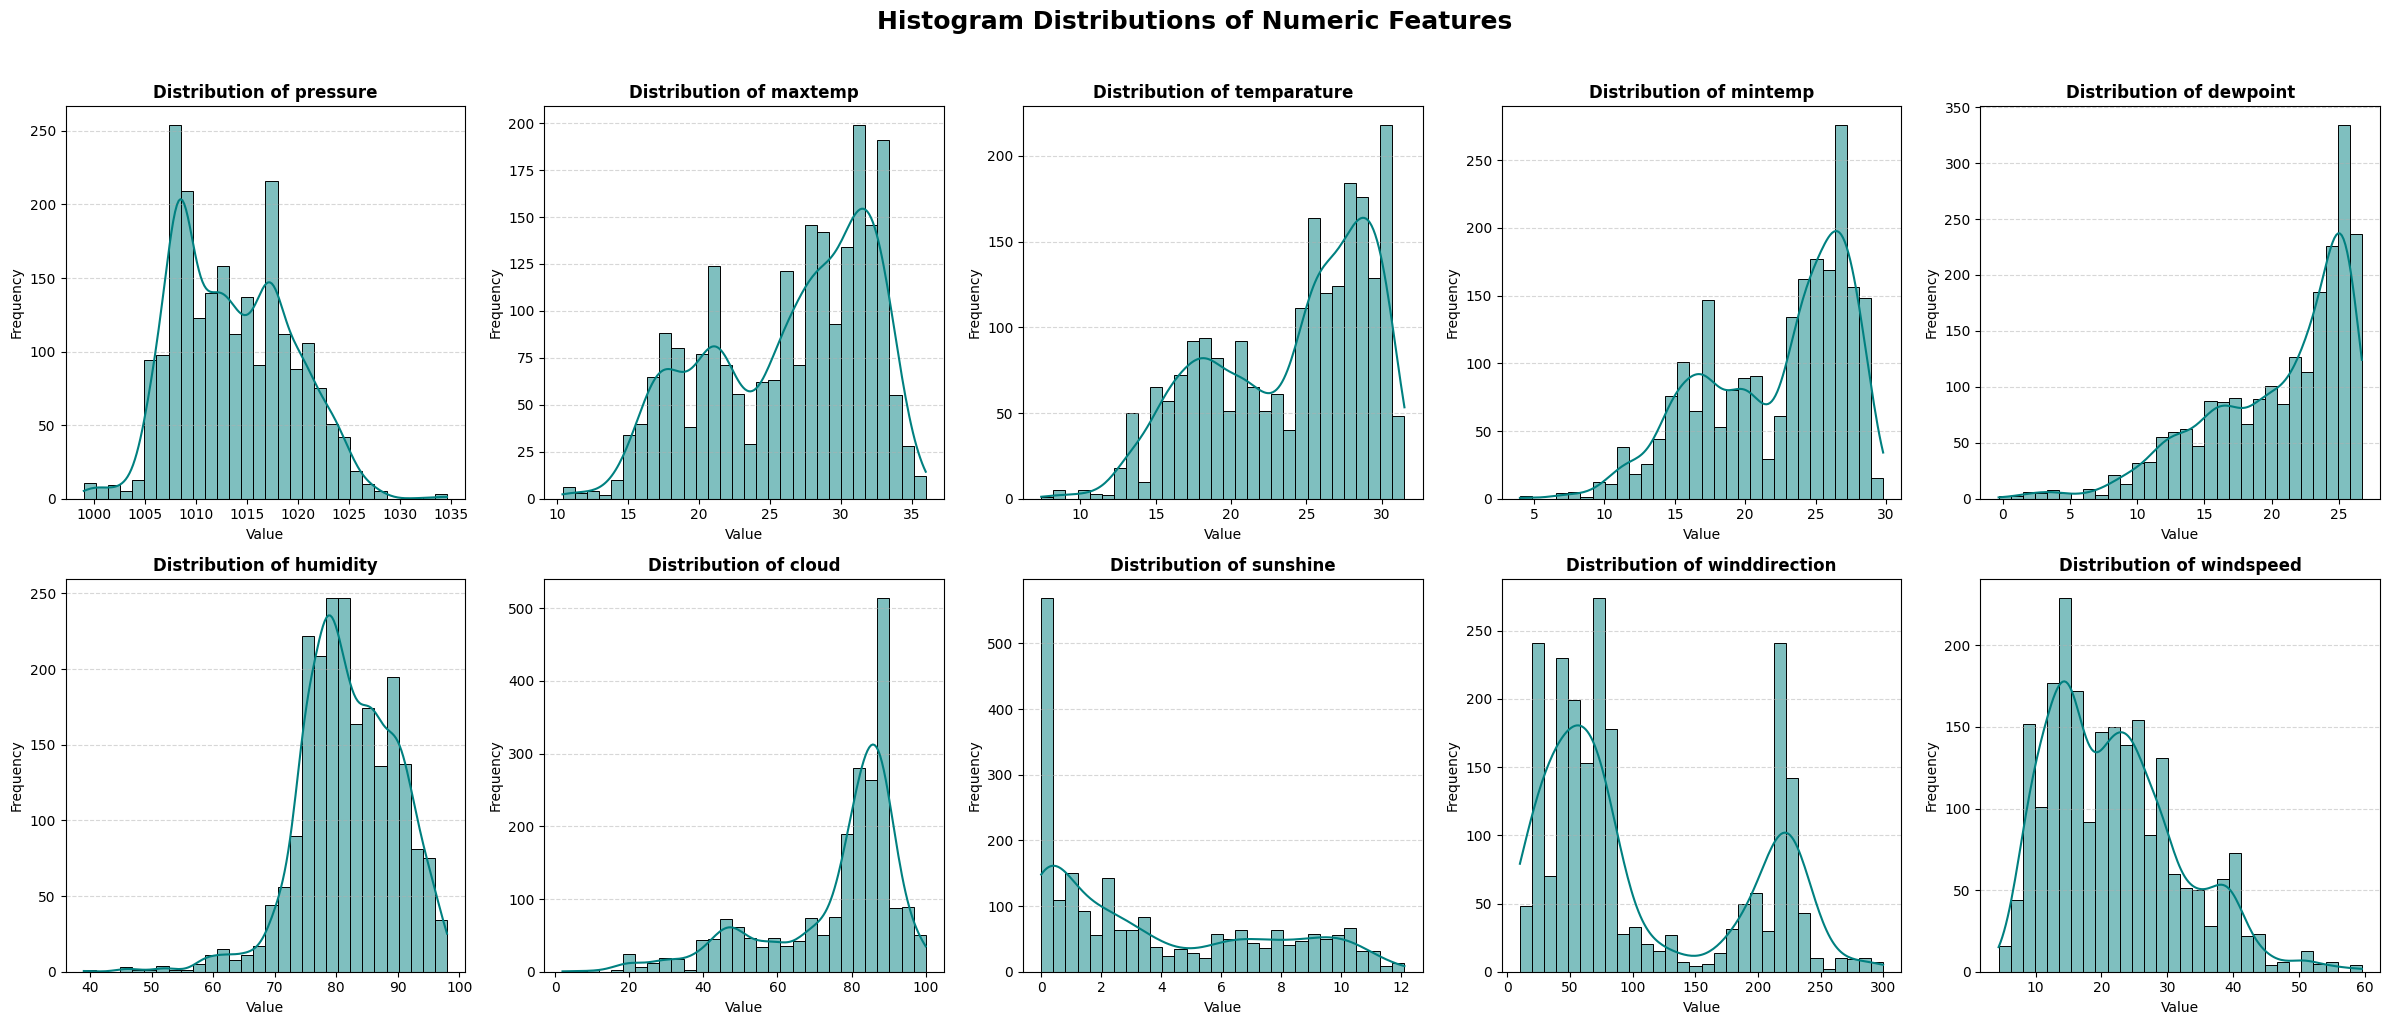

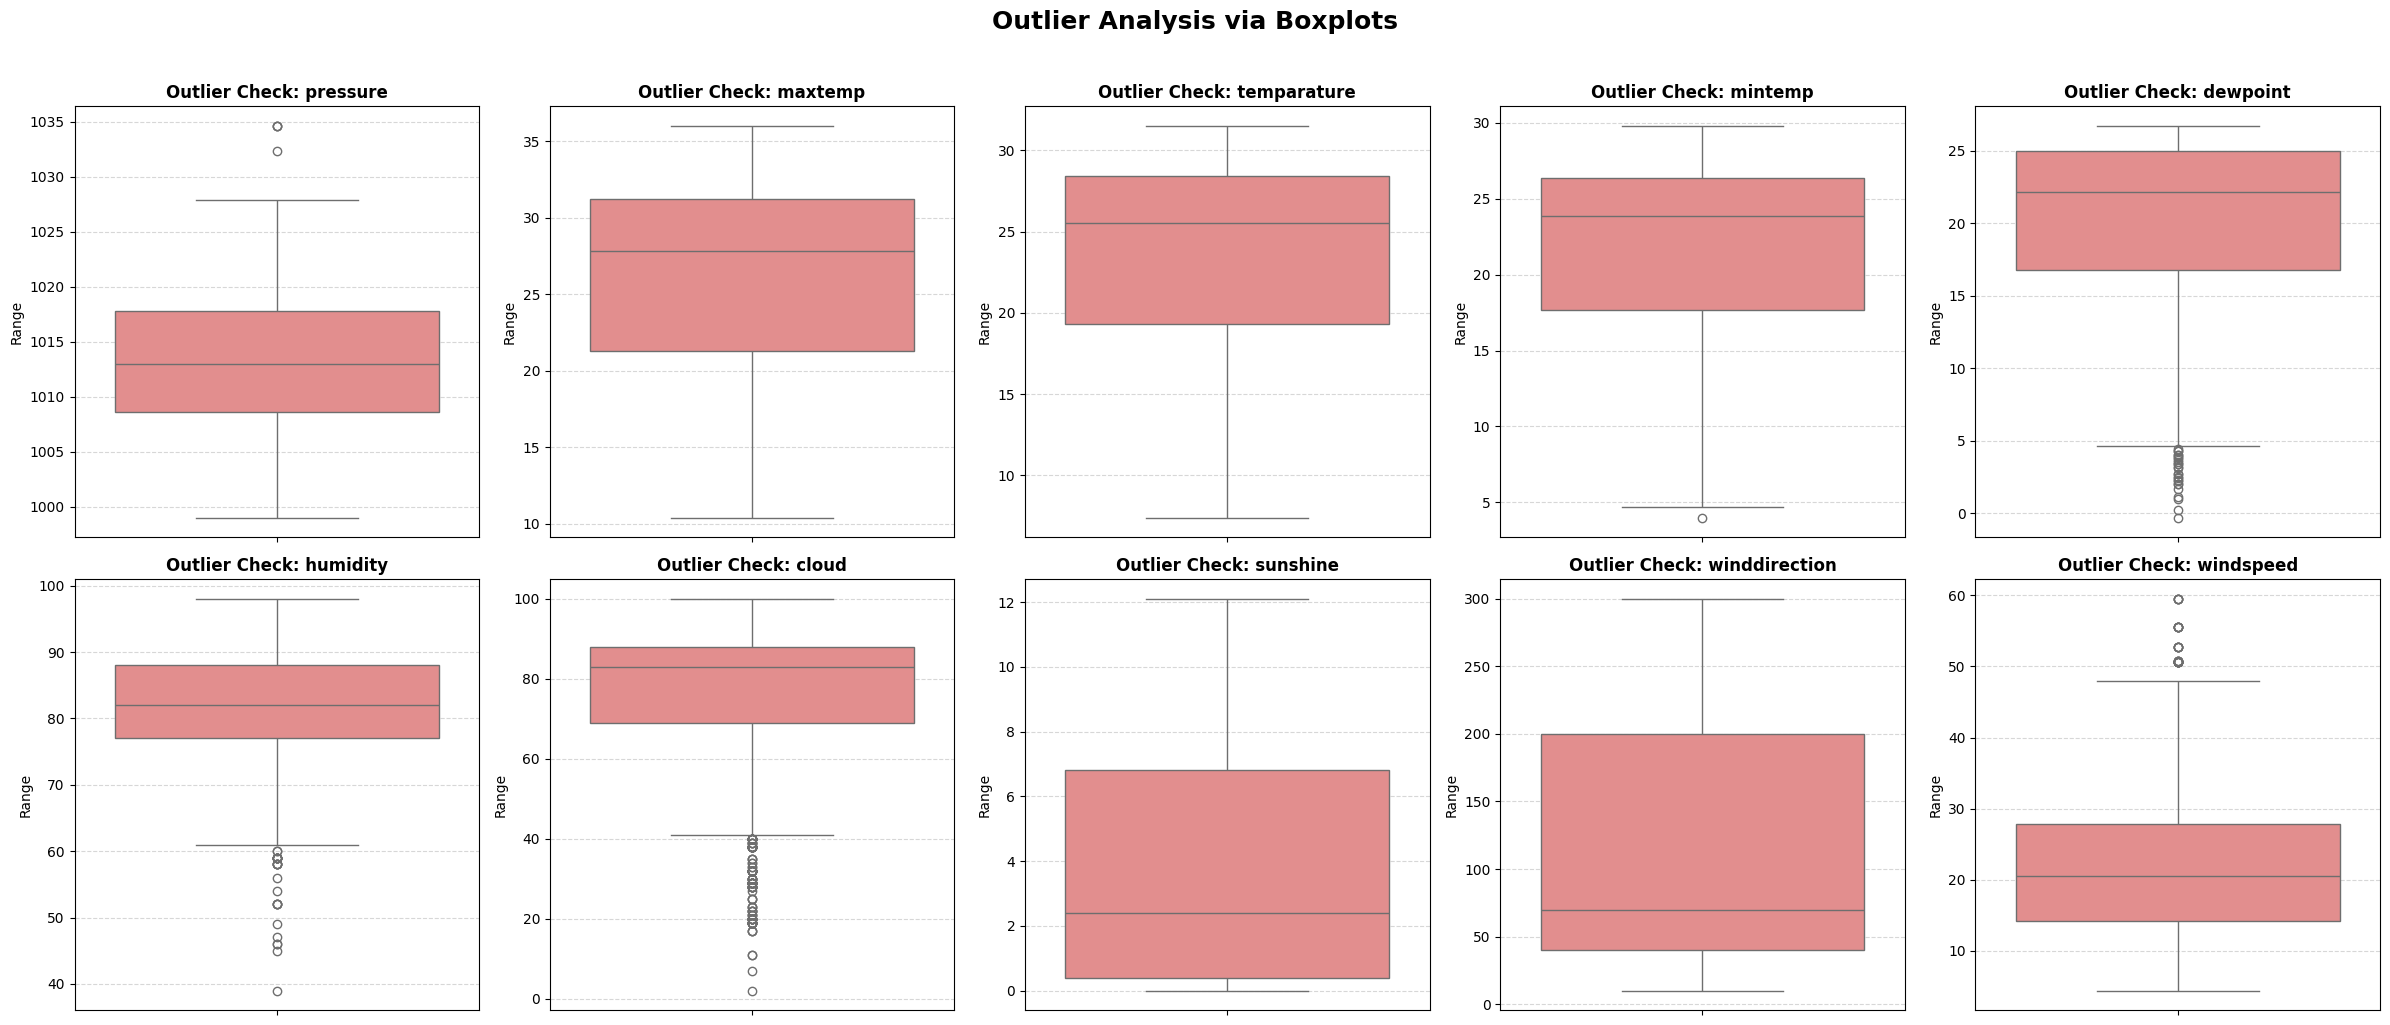

In [13]:
num_features = train_df.drop(columns=['id', 'day', 'rainfall'], axis=1, errors='ignore').columns.tolist()

# Histogram
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplots
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

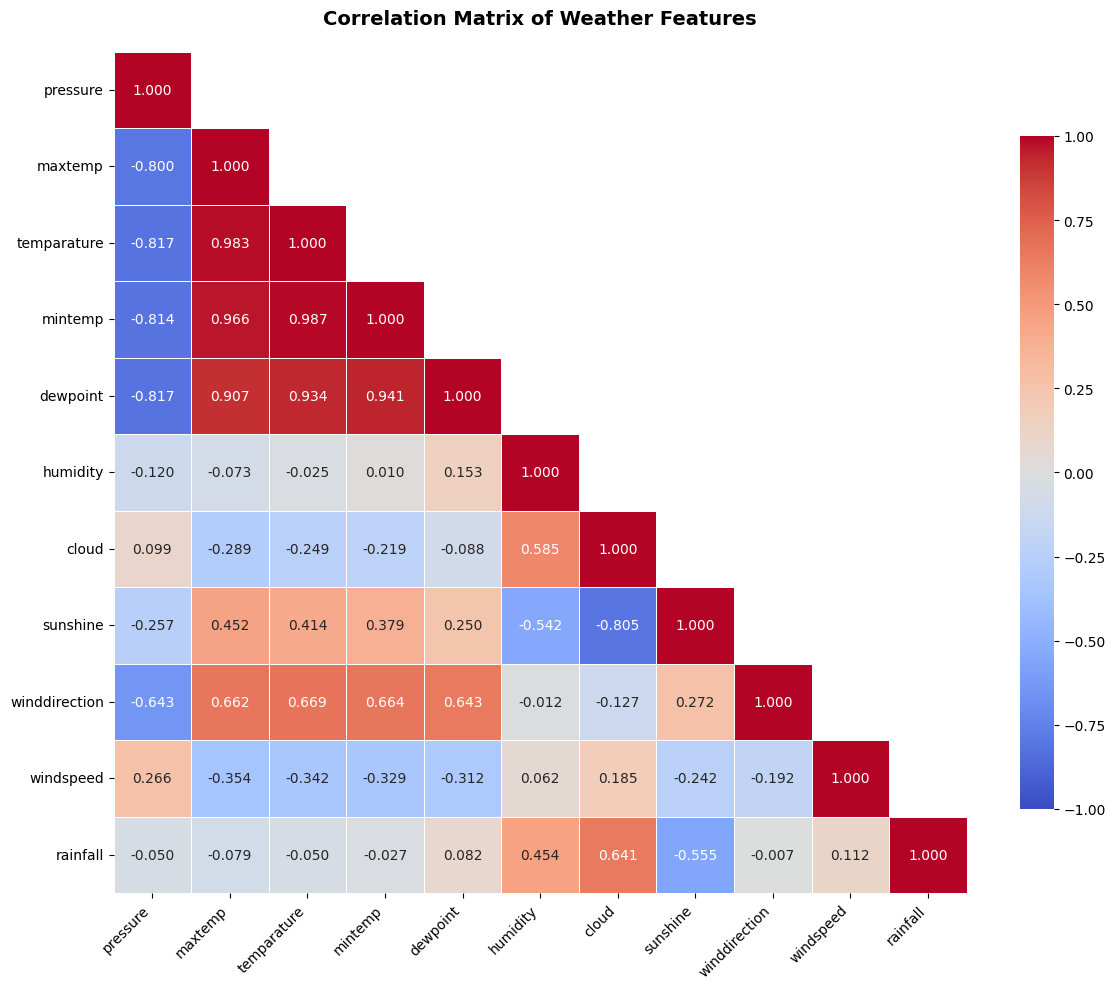

In [14]:
numerical_df = train_df.select_dtypes(include=['number']).drop(columns=['id', 'day'], errors='ignore')

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8} 
)

# Add titles and adjust axis labels for better readability
plt.title('Correlation Matrix of Weather Features', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

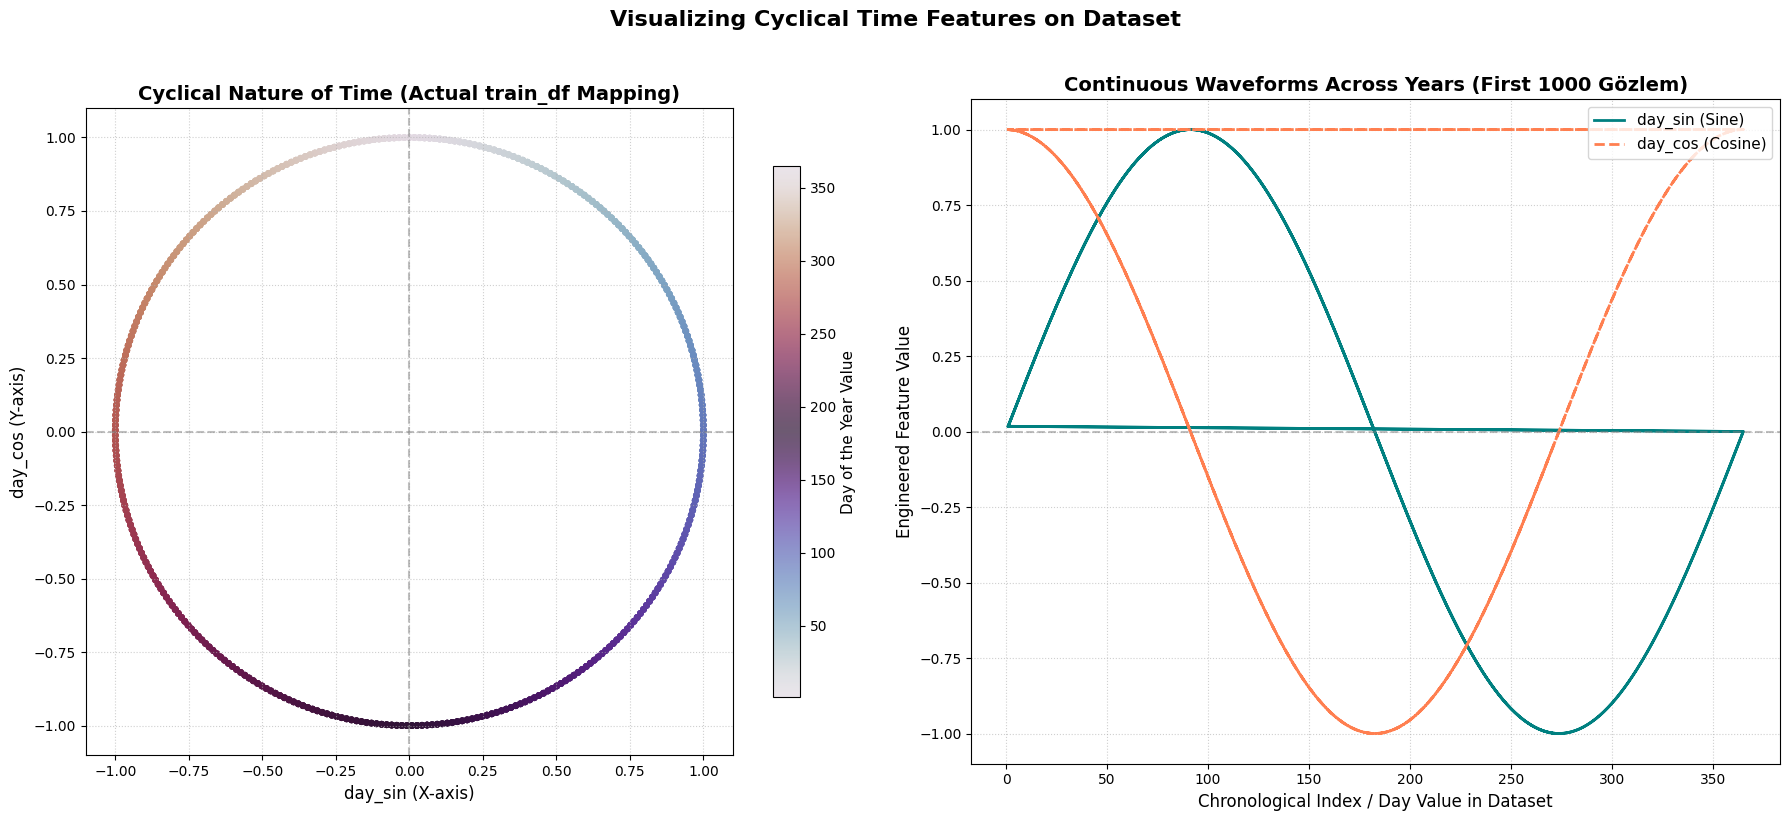

In [15]:
actual_days = train_df['day']
day_sin = np.sin(2 * np.pi * actual_days / 365.0)
day_cos = np.cos(2 * np.pi * actual_days / 365.0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

scatter = axes[0].scatter(day_sin, day_cos, c=actual_days, cmap='twilight', s=15, alpha=0.7)
axes[0].set_title('Cyclical Nature of Time (Actual train_df Mapping)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('day_sin (X-axis)', fontsize=12)
axes[0].set_ylabel('day_cos (Y-axis)', fontsize=12)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_aspect('equal', adjustable='box') # Keeps the circle perfectly proportional

cbar = fig.colorbar(scatter, ax=axes[0], shrink=0.8)
cbar.set_label('Day of the Year Value', fontsize=11)

plot_range = 1000

axes[1].plot(actual_days.iloc[:plot_range], day_sin.iloc[:plot_range], label='day_sin (Sine)', color='teal', linewidth=2)
axes[1].plot(actual_days.iloc[:plot_range], day_cos.iloc[:plot_range], label='day_cos (Cosine)', color='coral', linewidth=2, linestyle='--')
axes[1].set_title(f'Continuous Waveforms Across Years (First {plot_range} Gözlem)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Chronological Index / Day Value in Dataset', fontsize=12)
axes[1].set_ylabel('Engineered Feature Value', fontsize=12)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right', fontsize=11)

plt.suptitle('Visualizing Cyclical Time Features on Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

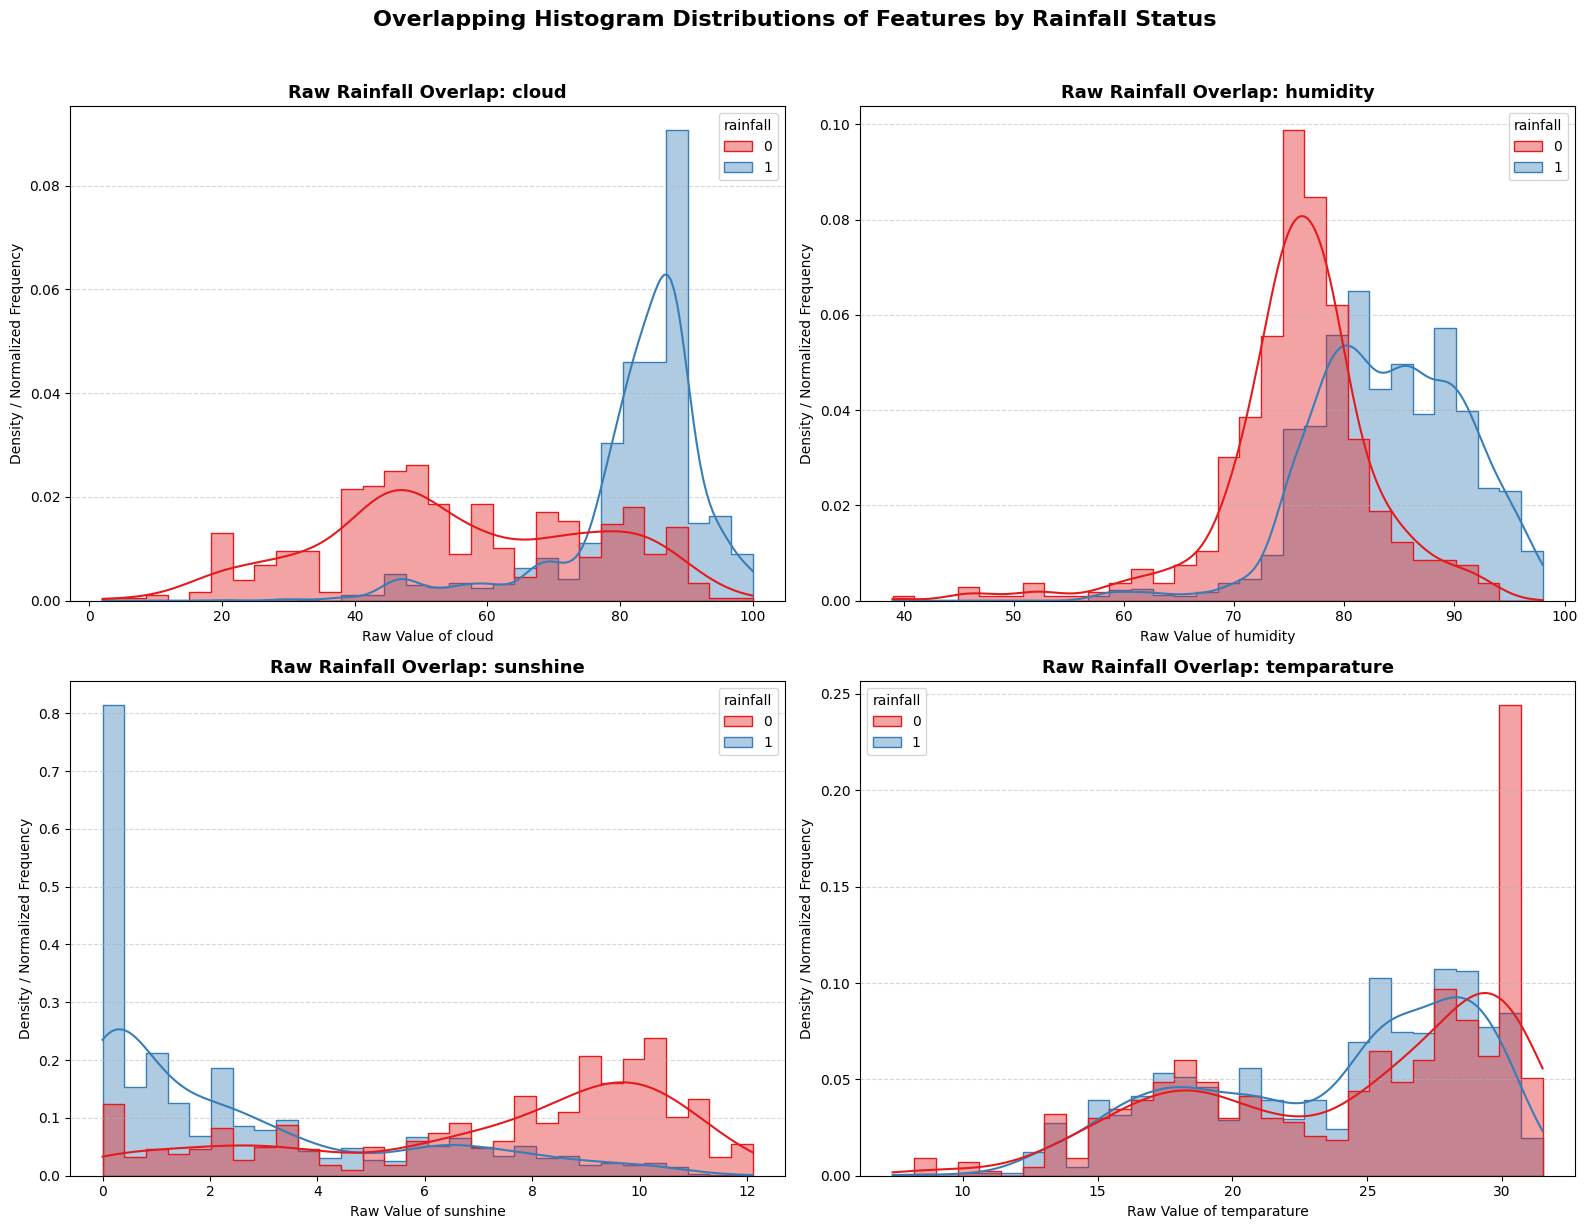

In [16]:
features = ['cloud', 'humidity', 'sunshine', 'temparature']


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    # Plotting overlapping histograms for the raw data based on rainfall (0 vs 1)
    sns.histplot(
        data=train_df, 
        x=col, 
        hue='rainfall', 
        kde=True, 
        element="step",
        stat="density",
        common_norm=False, 
        palette='Set1', 
        alpha=0.4, 
        bins=30,
        ax=axes[i]
    )
    
   
    axes[i].set_title(f'Raw Rainfall Overlap: {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'Raw Value of {col}')
    axes[i].set_ylabel('Density / Normalized Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Overlapping Histogram Distributions of Features by Rainfall Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering (FE) & Data Preprocessing

In [17]:
# Transforming the linear 1-365 'day' column into cyclical sine and cosine signals
train_df['day_sin'] = np.sin(2 * np.pi * train_df['day'] / 365.0)
train_df['day_cos'] = np.cos(2 * np.pi * train_df['day'] / 365.0)

In [18]:
# Thermal Dynamics
train_df['temp_range'] = train_df['maxtemp'] - train_df['mintemp']
train_df['dewpoint_depression'] = train_df['temparature'] - train_df['dewpoint']

# Atmospheric Ratio (Adding epsilon to avoid division by zero)
train_df['sunshine_cloud_ratio'] = train_df['sunshine'] / (train_df['cloud'] + 1.0)

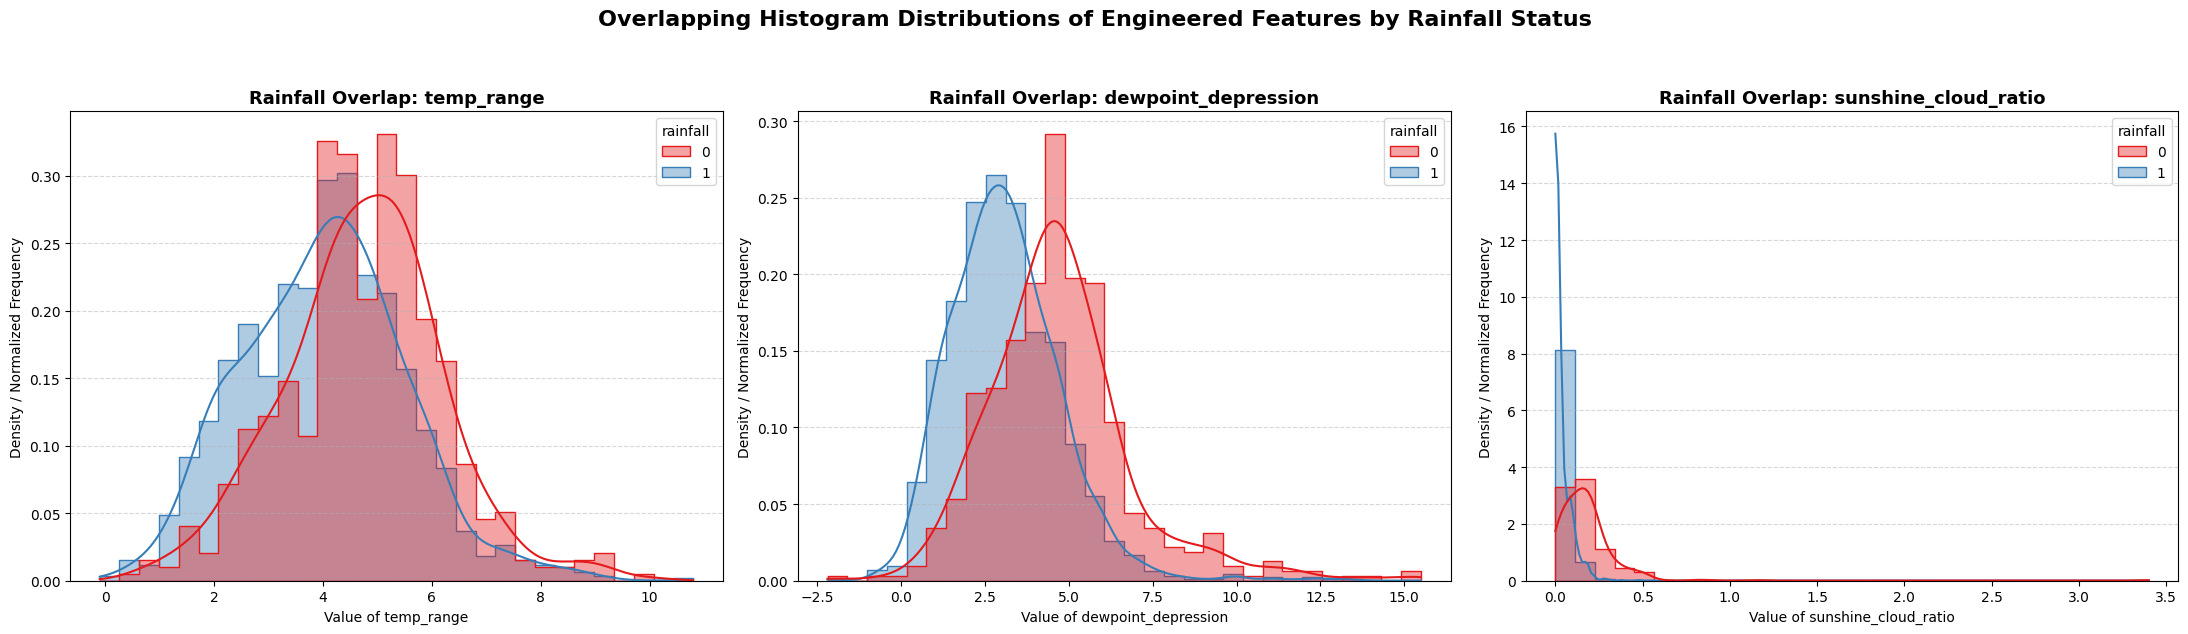

In [19]:
engineered_features = ['temp_range', 'dewpoint_depression', 'sunshine_cloud_ratio']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
axes = axes.flatten()

for i, col in enumerate(engineered_features):
    sns.histplot(
        data=train_df, 
        x=col, 
        hue='rainfall', 
        kde=True, 
        element="step",
        stat="density",
        common_norm=False, 
        palette='Set1', 
        alpha=0.4, 
        bins=30,
        ax=axes[i]
    )
    
    axes[i].set_title(f'Rainfall Overlap: {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'Value of {col}')
    axes[i].set_ylabel('Density / Normalized Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Overlapping Histogram Distributions of Engineered Features by Rainfall Status', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [20]:
rad_direction = np.radians(train_df['winddirection'])

train_df['wind_u'] = train_df['windspeed'] * np.cos(rad_direction) # Doğu-Batı bileşeni
train_df['wind_v'] = train_df['windspeed'] * np.sin(rad_direction) # Kuzey-Güney bileşeni

In [21]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2190 non-null   int64  
 1   day                   2190 non-null   int64  
 2   pressure              2190 non-null   float64
 3   maxtemp               2190 non-null   float64
 4   temparature           2190 non-null   float64
 5   mintemp               2190 non-null   float64
 6   dewpoint              2190 non-null   float64
 7   humidity              2190 non-null   float64
 8   cloud                 2190 non-null   float64
 9   sunshine              2190 non-null   float64
 10  winddirection         2190 non-null   float64
 11  windspeed             2190 non-null   float64
 12  rainfall              2190 non-null   int64  
 13  day_sin               2190 non-null   float64
 14  day_cos               2190 non-null   float64
 15  temp_range           

In [22]:
# Transforming the linear 1-365 'day' column into cyclical sine and cosine signals
test_df['day_sin'] = np.sin(2 * np.pi * test_df['day'] / 365.0)
test_df['day_cos'] = np.cos(2 * np.pi * test_df['day'] / 365.0)

# Converting winddirection from degrees to radians and decomposing into Cartesian vectors
rad_direction_test = np.radians(test_df['winddirection'])
test_df['wind_u'] = test_df['windspeed'] * np.cos(rad_direction_test) # East-West wind vector component
test_df['wind_v'] = test_df['windspeed'] * np.sin(rad_direction_test) # North-South wind vector component

# Diurnal Temperature Range (captures daily thermal swing)
test_df['temp_range'] = test_df['maxtemp'] - test_df['mintemp']

# Dewpoint Depression (measures air mass saturation levels)
test_df['dewpoint_depression'] = test_df['temparature'] - test_df['dewpoint']

# Sunshine-to-Cloud Ratio (quantifies clear-sky dominance; +1 prevents division by zero)
test_df['sunshine_cloud_ratio'] = test_df['sunshine'] / (test_df['cloud'] + 1.0)

In [23]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2190 non-null   int64  
 1   day                   2190 non-null   int64  
 2   pressure              2190 non-null   float64
 3   maxtemp               2190 non-null   float64
 4   temparature           2190 non-null   float64
 5   mintemp               2190 non-null   float64
 6   dewpoint              2190 non-null   float64
 7   humidity              2190 non-null   float64
 8   cloud                 2190 non-null   float64
 9   sunshine              2190 non-null   float64
 10  winddirection         2190 non-null   float64
 11  windspeed             2190 non-null   float64
 12  rainfall              2190 non-null   int64  
 13  day_sin               2190 non-null   float64
 14  day_cos               2190 non-null   float64
 15  temp_range           

In [24]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    730 non-null    int64  
 1   day                   730 non-null    int64  
 2   pressure              730 non-null    float64
 3   maxtemp               730 non-null    float64
 4   temparature           730 non-null    float64
 5   mintemp               730 non-null    float64
 6   dewpoint              730 non-null    float64
 7   humidity              730 non-null    float64
 8   cloud                 730 non-null    float64
 9   sunshine              730 non-null    float64
 10  winddirection         729 non-null    float64
 11  windspeed             730 non-null    float64
 12  day_sin               730 non-null    float64
 13  day_cos               730 non-null    float64
 14  wind_u                729 non-null    float64
 15  wind_v                7

In [25]:
test_df[test_df['winddirection'].isna()]

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,day_sin,day_cos,wind_u,wind_v,temp_range,dewpoint_depression,sunshine_cloud_ratio
517,2707,153,1007.8,32.9,30.6,28.9,22.0,65.0,75.0,8.2,NaN,17.2,0.486273,-0.873807,NaN,NaN,4.0,8.6,0.107895


In [26]:
test_df['winddirection'] = test_df['winddirection'].interpolate(method='linear')

rad_direction_test = np.radians(test_df['winddirection'])

test_df['wind_u'] = test_df['windspeed'] * np.cos(rad_direction_test)
test_df['wind_v'] = test_df['windspeed'] * np.sin(rad_direction_test)

In [27]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    730 non-null    int64  
 1   day                   730 non-null    int64  
 2   pressure              730 non-null    float64
 3   maxtemp               730 non-null    float64
 4   temparature           730 non-null    float64
 5   mintemp               730 non-null    float64
 6   dewpoint              730 non-null    float64
 7   humidity              730 non-null    float64
 8   cloud                 730 non-null    float64
 9   sunshine              730 non-null    float64
 10  winddirection         730 non-null    float64
 11  windspeed             730 non-null    float64
 12  day_sin               730 non-null    float64
 13  day_cos               730 non-null    float64
 14  wind_u                730 non-null    float64
 15  wind_v                7

In [28]:
columns_to_drop = ['id', 'day', 'winddirection', 'windspeed', 'maxtemp', 'mintemp']
real_test_ids = test_df['id'].copy()

train_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
test_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

In [29]:
y = train_df['rainfall']
x = train_df.drop(columns=['rainfall'], errors='ignore')

## 5. Model Training, Optimization & Deployment Strategy

In [30]:
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight

def algo_test(x, y):

    b = BernoulliNB()
    l = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
    d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
    r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
    kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ab = AdaBoostClassifier(random_state=42)
    svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
    lgb = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)

    models = [b, l, d, r, gb, kn, ab, svc, xgb, lgb]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "LinearSVC", "XGBClassifier", "LGBMClassifier"
    ]


    split_idx = int(len(x) * 0.80)
    
    x_train_split, x_val_split = x.iloc[:split_idx], x.iloc[split_idx:]
    y_train_split, y_val_split = y.iloc[:split_idx], y.iloc[split_idx:] # FIXED HERE!
    
    accuracy, precision, recall, f1 = [], [], [], []
    successful_models = []
    successful_names = []

    print(f"Data Timeline Ready. Train Rows: {x_train_split.shape[0]} | Val Rows: {x_val_split.shape[0]}\n")
    computed_weights = compute_sample_weight(class_weight='balanced', y=y_train_split)
    
    # Training Loop
    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            if name in ["XGBClassifier", "GradientBoostingClassifier", "AdaBoostClassifier"]:
                model_fitted = model.fit(x_train_split, y_train_split, sample_weight=computed_weights)
            else:
                model_fitted = model.fit(x_train_split, y_train_split)
                
            prediction = model_fitted.predict(x_val_split)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, zero_division=0))
            recall.append(recall_score(y_val_split, prediction, zero_division=0))
            f1.append(f1_score(y_val_split, prediction, zero_division=0))
            
            successful_models.append(model_fitted)
            successful_names.append(name)
            
        except Exception as e:
            print(f" [!] Error executing pipeline for {name}: {e}")
            continue


    metrics = pd.DataFrame(index=successful_names)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model_Object"] = successful_models

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("\n" + "="*50)
    best_model_name = metrics.index[0]
    print(f"TRUE MOST SUCCESSFUL MODEL BASED ON F1: {best_model_name}")
    print("="*50 + "\n")
    
    best_model_object = metrics.loc[best_model_name, "Model_Object"]
    final_prediction = best_model_object.predict(x_val_split)
    
    print(f"Real Confusion Matrix ({best_model_name}):")
    print(confusion_matrix(y_val_split, final_prediction))
    print(f"\nReal Classification Report ({best_model_name}):")
    print(classification_report(y_val_split, final_prediction))
    
    report_df = metrics.drop(columns=["Model_Object"])
    return report_df, metrics

In [31]:
model_perf_report, trained_metrics_df = algo_test(x, y)

Data Timeline Ready. Train Rows: 1752 | Val Rows: 438

--> Training BernoulliNB...
--> Training LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--> Training DecisionTreeClassifier...
--> Training RandomForestClassifier...
--> Training GradientBoostingClassifier...
--> Training KNeighborsClassifier...
--> Training AdaBoostClassifier...
--> Training LinearSVC...
--> Training XGBClassifier...
--> Training LGBMClassifier...

TRUE MOST SUCCESSFUL MODEL BASED ON F1: RandomForestClassifier

Real Confusion Matrix (RandomForestClassifier):
[[ 55  37]
 [ 22 324]]

Real Classification Report (RandomForestClassifier):
              precision    recall  f1-score   support

           0       0.71      0.60      0.65        92
           1       0.90      0.94      0.92       346

    accuracy                           0.87       438
   macro avg       0.81      0.77      0.78       438
weighted avg       0.86      0.87      0.86       438



In [32]:
model_perf_report

,Accuracy,Precision,Recall,F1
RandomForestClassifier,0.865297,0.897507,0.936416,0.916549
KNeighborsClassifier,0.863014,0.899441,0.930636,0.914773
GradientBoostingClassifier,0.858447,0.930303,0.887283,0.908284
LGBMClassifier,0.847032,0.918919,0.884393,0.901325
LinearSVC,0.842466,0.923547,0.872832,0.897474
LogisticRegression,0.842466,0.926154,0.869942,0.897168
XGBClassifier,0.840183,0.918182,0.875723,0.896450
AdaBoostClassifier,0.831050,0.933121,0.846821,0.887879
BernoulliNB,0.792237,0.791762,1.000000,0.883780
DecisionTreeClassifier,0.789954,0.891975,0.835260,0.862687


In [35]:
split_idx = int(len(x) * 0.80)

x_train_split, x_val_split = x.iloc[:split_idx], x.iloc[split_idx:]
y_train_split, y_val_split = y.iloc[:split_idx], y.iloc[split_idx:]

In [37]:
r = RandomForestClassifier(n_estimators=100, max_samples=0.2, class_weight='balanced', n_jobs=-1, random_state=42)

In [40]:
r.fit(x_train_split, y_train_split)

RandomForestClassifier(class_weight='balanced', max_samples=0.2, n_jobs=-1,
                       random_state=42)

In [41]:
y_pred = r.predict(x_val_split)
y_probs = r.predict_proba(x_val_split)[:, 1]

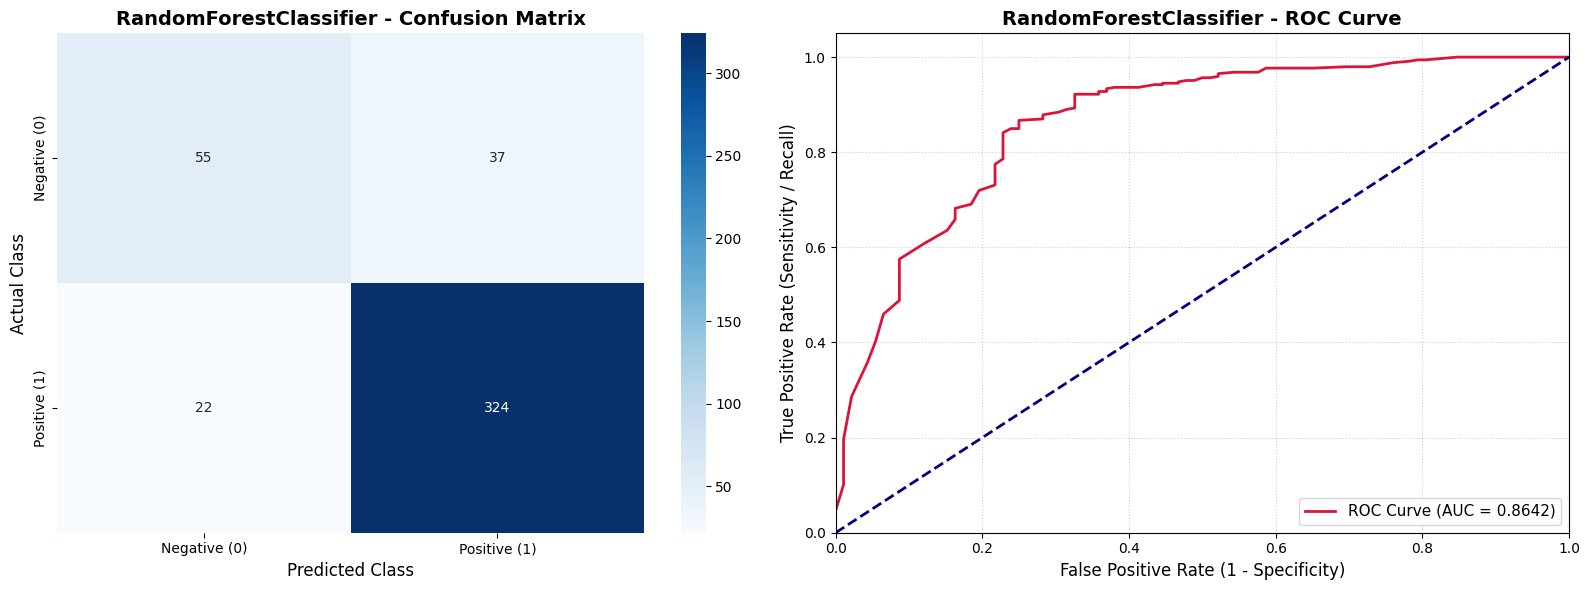

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# cm
cm = confusion_matrix(y_val_split, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
axes[0].set_title('RandomForestClassifier - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Actual Class', fontsize=12)

# roc

fpr, tpr, thresholds = roc_curve(y_val_split, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
axes[1].set_title('RandomForestClassifier - ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [44]:
y_train_final = train_df['rainfall']
x_train_final = train_df.drop(columns=['rainfall'], errors='ignore')

In [45]:
x_test_final = test_df[x_train_final.columns].copy()

In [46]:
# Best model
final_model = RandomForestClassifier(
    n_estimators=100, 
    max_samples=0.2, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

In [47]:
final_model.fit(x_train_final, y_train_final)

RandomForestClassifier(class_weight='balanced', max_samples=0.2, n_jobs=-1,
                       random_state=42)

In [48]:
predictions = final_model.predict(x_test_final)

In [49]:
submission_df = pd.DataFrame({
    'id': real_test_ids,
    'rainfall': predictions
})

submission_df.to_csv('submission.csv', index=False)

In [50]:
submission_df

,id,rainfall
0,2190,1
1,2191,1
2,2192,1
3,2193,0
4,2194,0
...,...,...
725,2915,1
726,2916,1
727,2917,1
728,2918,1


In [51]:
joblib.dump(final_model, 'RF_rainfall.joblib')

['RF_rainfall.joblib']

In [52]:
with open('RF_rainfall.pkl', 'wb') as f:
    pickle.dump(final_model, f)